# Italy Test Set Evaluation

Runs the trained model on the geographic holdout 

## 1. Imports and setup

In [16]:
import os
import numpy as np
import torch
import torch.nn as nn
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [17]:
import torch
import pandas as pd
import numpy as np

BEST_MODEL_PATH = 'final_model_lilac56.pt'

ck = torch.load(BEST_MODEL_PATH, map_location='cpu')
cfg = ck.get('config', {})
print('Model file:   ', BEST_MODEL_PATH)
print('Config:       ', cfg)
print('val_rmse:     ', ck.get('val_rmse'))
print('val_city_rmse:', ck.get('val_city_rmse'))

Model file:    final_model_lilac56.pt
Config:        {'patch_size': 8, 'base_channels': 32, 'n_layers': 2, 'loss_fn': 'huber', 'delta': 0.05, 'lr': 0.00018672478544905867, 'weight_decay': 2.5576212047230037e-06, 'dropout': 0.1, 'batch_size': 32}
val_rmse:      0.030712822452187538
val_city_rmse: 0.13167500495910645


## 2. Model definition

In [18]:
class CNNSweep(nn.Module):
    def __init__(self, config):
        super().__init__()
        d        = config.get('dropout', 0.3)
        n_layers = config.get('n_layers', 4)
        base_ch  = config.get('base_channels', 16)

        layers = []
        in_ch  = 9
        out_ch = base_ch
        for i in range(n_layers):
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.Dropout(d),
            ]
            if i < n_layers - 1:
                layers.append(nn.MaxPool2d(2, 2))
            in_ch  = out_ch
            out_ch = min(out_ch * 2, 256)

        self.conv_layers = nn.Sequential(*layers)
        self.final_ch    = in_ch

        self.fc_layers = nn.Sequential(
            nn.Linear(self.final_ch, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(d),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)

## 3. Paths and model loading

In [19]:
MODEL_PATH = BEST_MODEL_PATH
GDP_PATH   = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'
POP_PATH   = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'
LC_PATH    = r'READY_data\landuse_onehot\clipped_history_2020_onehot.tif'
CISI_PATH  = r'READY_data\labels\2024_CISI_010deg_nearest.tif'
SHP_PATH   = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'

checkpoint = torch.load(MODEL_PATH, map_location=device)
config     = checkpoint.get('config', {})
PATCH_SIZE = config.get('patch_size', 16)
HALF       = PATCH_SIZE // 2

model = CNNSweep(config).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Model loaded from {MODEL_PATH}')
print(f'Config: {config}')

Model loaded from final_model_lilac56.pt
Config: {'patch_size': 8, 'base_channels': 32, 'n_layers': 2, 'loss_fn': 'huber', 'delta': 0.05, 'lr': 0.00018672478544905867, 'weight_decay': 2.5576212047230037e-06, 'dropout': 0.1, 'batch_size': 32}


## 4. Load data and extract Italy pixels

In [20]:
with rasterio.open(GDP_PATH) as src:
    gdp = src.read(1).astype(np.float32)
with rasterio.open(POP_PATH) as src:
    pop = src.read(1).astype(np.float32)
with rasterio.open(LC_PATH) as src:
    lc = src.read().astype(np.float32)
with rasterio.open(CISI_PATH) as src:
    cisi      = src.read(1).astype(np.float32)
    transform = src.transform

input_stack = np.nan_to_num(np.concatenate([gdp[np.newaxis], pop[np.newaxis], lc], axis=0), nan=0.0)  # (9, H, W)

valid_mask = ~np.isnan(gdp) & ~np.isnan(pop) & ~np.isnan(cisi)
valid_idx  = np.argwhere(valid_mask)

# Geolocate pixels and identify Italy
rows, cols = valid_idx[:, 0], valid_idx[:, 1]
xs, ys = rasterio.transform.xy(transform, rows, cols)
points = gpd.GeoDataFrame(
    {"idx": np.arange(len(rows))},
    geometry=gpd.points_from_xy(xs, ys),
    crs="EPSG:4326"
)
world = gpd.read_file(SHP_PATH)[["NAME", "geometry"]]
joined = gpd.sjoin(points, world, how="left", predicate="within")
country_names = joined["NAME"].fillna("").values

italy_idx = valid_idx[country_names == "Italy"]
print(f"Total valid pixels: {len(valid_idx):,}")
print(f"Italy test pixels:  {len(italy_idx):,}")


Total valid pixels: 77,935
Italy test pixels:  3,267


## 5. Run inference on Italy pixels

In [21]:
patches, coords, preds_list = [], [], []

for i, j in italy_idx:
    pad_top    = max(0, HALF - i)
    pad_bottom = max(0, (i + HALF) - input_stack.shape[1])
    pad_left   = max(0, HALF - j)
    pad_right  = max(0, (j + HALF) - input_stack.shape[2])
    i0 = max(0, i - HALF); i1 = min(input_stack.shape[1], i + HALF)
    j0 = max(0, j - HALF); j1 = min(input_stack.shape[2], j + HALF)
    patch = input_stack[:, i0:i1, j0:j1].copy()
    if pad_top or pad_bottom or pad_left or pad_right:
        patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode="edge")
    patches.append(patch)
    coords.append((i, j))

    if len(patches) == 512:
        batch = torch.FloatTensor(np.stack(patches)).to(device)
        with torch.no_grad():
            preds_list.extend(model(batch).cpu().numpy().flatten())
        patches, coords = [], []

if patches:
    batch = torch.FloatTensor(np.stack(patches)).to(device)
    with torch.no_grad():
        preds_list.extend(model(batch).cpu().numpy().flatten())

preds   = np.array(preds_list)
targets = np.array([cisi[i, j] for i, j in italy_idx])
print(f"Inference done. {len(preds):,} predictions.")


Inference done. 3,267 predictions.


## 6. Metrics

In [22]:
valid   = ~np.isnan(preds) & ~np.isnan(targets)
preds   = preds[valid]
targets = targets[valid]
print(f'Valid predictions: {valid.sum():,} / {len(valid):,}')

city_mask  = targets > 0.15
city_mask2 = targets > 0.20
rural_mask = ~city_mask

rmse_global    = float(np.sqrt(np.mean((targets - preds) ** 2)))
rmse_city      = float(np.sqrt(np.mean((targets[city_mask] - preds[city_mask]) ** 2))) if city_mask.sum() > 0 else float('nan')
mae_global     = float(np.mean(np.abs(targets - preds)))
mae_city       = float(np.mean(np.abs(targets[city_mask] - preds[city_mask]))) if city_mask.sum() > 0 else float('nan')
pred_max       = float(preds.max())
underpr_15     = float(np.mean(targets[city_mask]  - preds[city_mask]))  if city_mask.sum()  > 0 else float('nan')
underpr_20     = float(np.mean(targets[city_mask2] - preds[city_mask2])) if city_mask2.sum() > 0 else float('nan')

print(f'{"Metric":<30} {"Global":>10} {"City (>0.15)":>14}')
print('-' * 56)
print(f'{"RMSE":<30} {rmse_global:>10.4f} {rmse_city:>14.4f}')
print(f'{"MAE":<30} {mae_global:>10.4f} {mae_city:>14.4f}')
print(f'{"pred_max":<30} {pred_max:>10.4f}')
print(f'{"Mean underprediction t=0.15":<30} {underpr_15:>10.4f}')
print(f'{"Mean underprediction t=0.20":<30} {underpr_20:>10.4f}')
print(f'{"N city pixels (>0.15)":<30} {city_mask.sum():>10,}')
print(f'{"N total pixels":<30} {len(targets):>10,}')

Valid predictions: 3,267 / 3,267
Metric                             Global   City (>0.15)
--------------------------------------------------------
RMSE                               0.0370         0.1086
MAE                                0.0254         0.0906
pred_max                           0.2525
Mean underprediction t=0.15        0.0872
Mean underprediction t=0.20        0.1194
N city pixels (>0.15)                 152
N total pixels                      3,267


## 7. Scatter plot — predicted vs actual

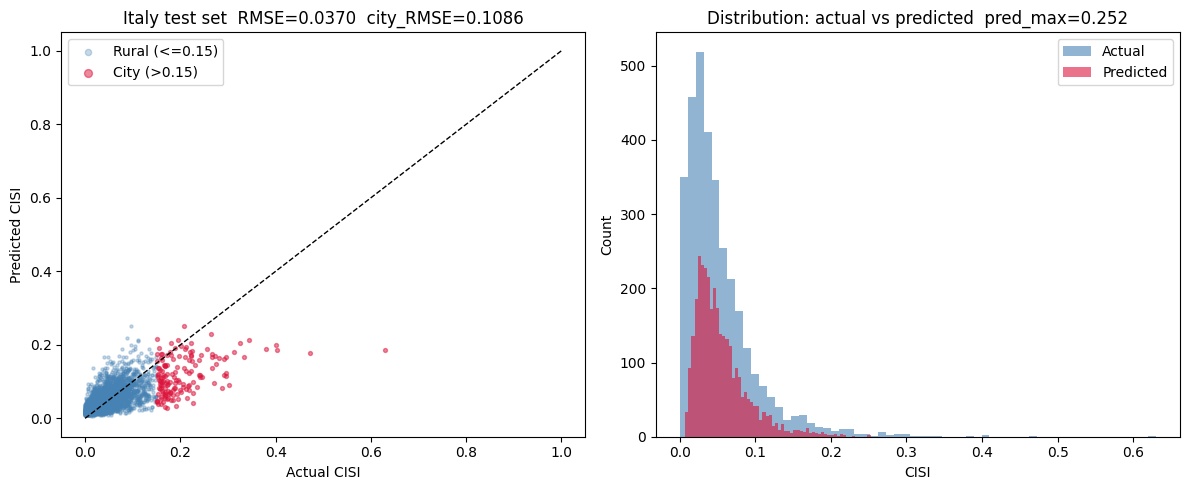

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(targets[rural_mask], preds[rural_mask], alpha=0.3, s=5, color='steelblue', label='Rural (<=0.15)')
axes[0].scatter(targets[city_mask],  preds[city_mask],  alpha=0.5, s=8, color='crimson',   label='City (>0.15)')
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_xlabel('Actual CISI'); axes[0].set_ylabel('Predicted CISI')
axes[0].set_title(f'Italy test set  RMSE={rmse_global:.4f}  city_RMSE={rmse_city:.4f}')
axes[0].legend(markerscale=2)

axes[1].hist(targets, bins=60, alpha=0.6, label='Actual',    color='steelblue')
axes[1].hist(preds,   bins=60, alpha=0.6, label='Predicted', color='crimson')
axes[1].set_xlabel('CISI'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Distribution: actual vs predicted  pred_max={pred_max:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/italy_test_scatter_11_5_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Spatial map — predictions and errors over Italy

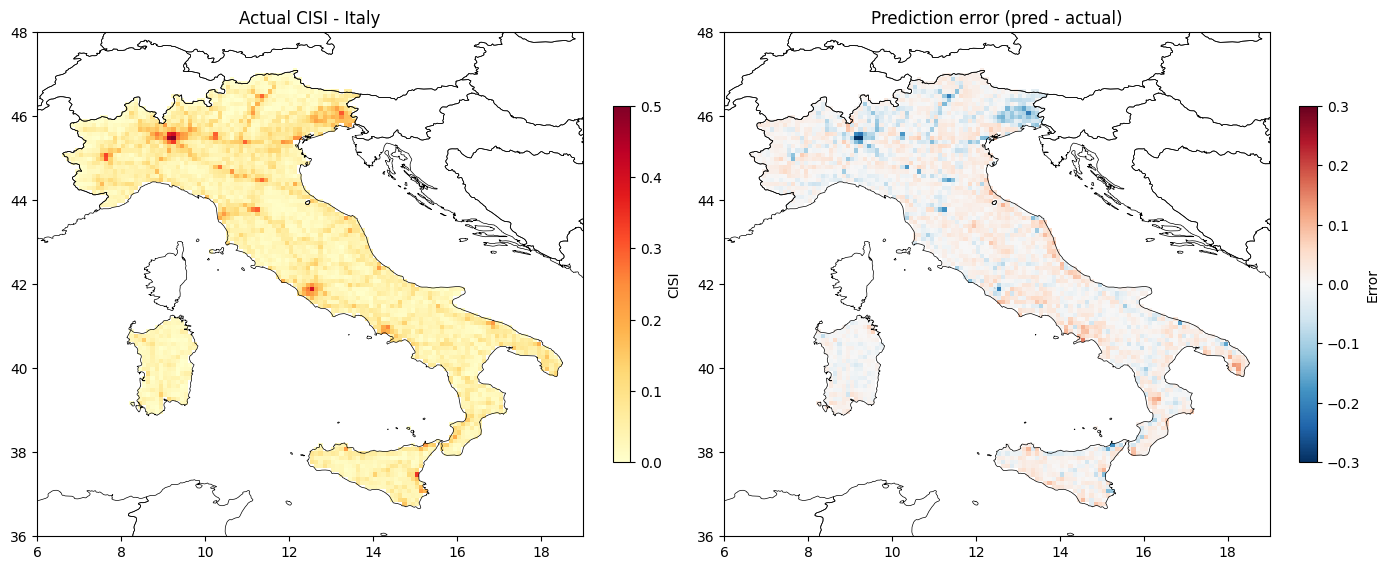

In [24]:
with rasterio.open(CISI_PATH) as src:
    H, W   = src.height, src.width
    bounds = src.bounds

pred_map   = np.full((H, W), np.nan)
error_map  = np.full((H, W), np.nan)
actual_map = np.full((H, W), np.nan)

for (i, j), p, t in zip(italy_idx, preds, targets):
    pred_map[i, j]   = p
    error_map[i, j]  = p - t
    actual_map[i, j] = t

world_shp = gpd.read_file(SHP_PATH)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(actual_map, cmap='YlOrRd', vmin=0, vmax=0.5,
                     origin='upper', extent=ext, aspect='auto')
world_shp.boundary.plot(ax=axes[0], linewidth=0.5, color='black')
axes[0].set_xlim(6, 19); axes[0].set_ylim(36, 48)
axes[0].set_title('Actual CISI - Italy')
plt.colorbar(im0, ax=axes[0], label='CISI', fraction=0.03)

im1 = axes[1].imshow(error_map, cmap='RdBu_r', vmin=-0.3, vmax=0.3,
                     origin='upper', extent=ext, aspect='auto')
world_shp.boundary.plot(ax=axes[1], linewidth=0.5, color='black')
axes[1].set_xlim(6, 19); axes[1].set_ylim(36, 48)
axes[1].set_title('Prediction error (pred - actual)')
plt.colorbar(im1, ax=axes[1], label='Error', fraction=0.03)

plt.tight_layout()
plt.savefig('figures/italy_test_map_11_5_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 8b. Italy map — actual vs predicted side by side

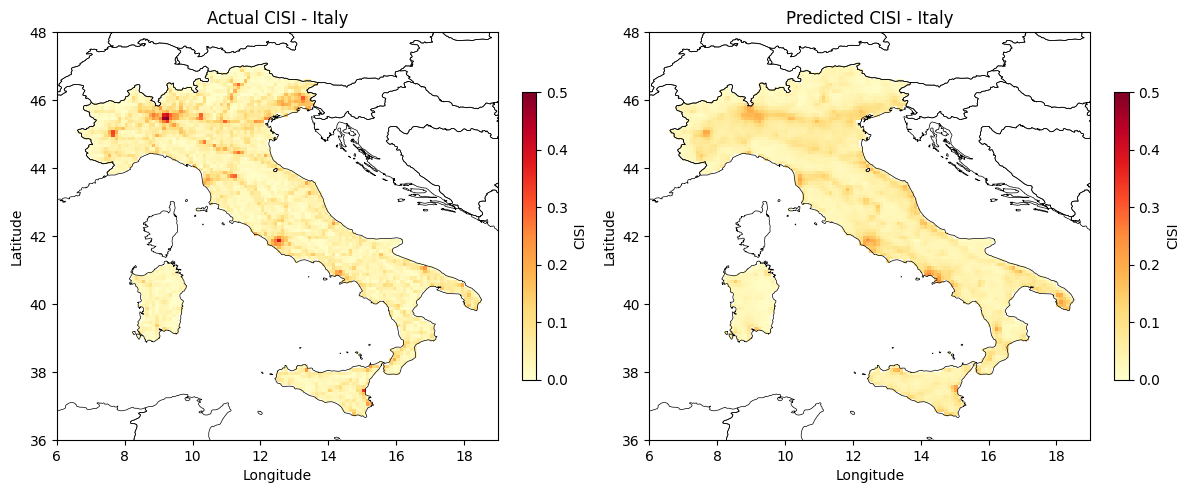

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

for ax, data, title in [
    (axes[0], actual_map, 'Actual CISI - Italy'),
    (axes[1], pred_map,   'Predicted CISI - Italy'),
]:
    im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=0.5,
                   origin='upper', extent=ext, aspect='auto')
    world_shp.boundary.plot(ax=ax, linewidth=0.5, color='black')
    ax.set_xlim(6, 19); ax.set_ylim(36, 48)
    ax.set_title(title)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)

plt.tight_layout()
plt.savefig('figures/italy_test_result_map_11_5_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. CISI density vs prediction error

Shows how absolute and signed error relate to actual CISI value. The binned mean signed error reveals systematic over/underprediction at different CISI levels.

Pearson r (CISI vs signed error): -0.6965  p=0.00e+00


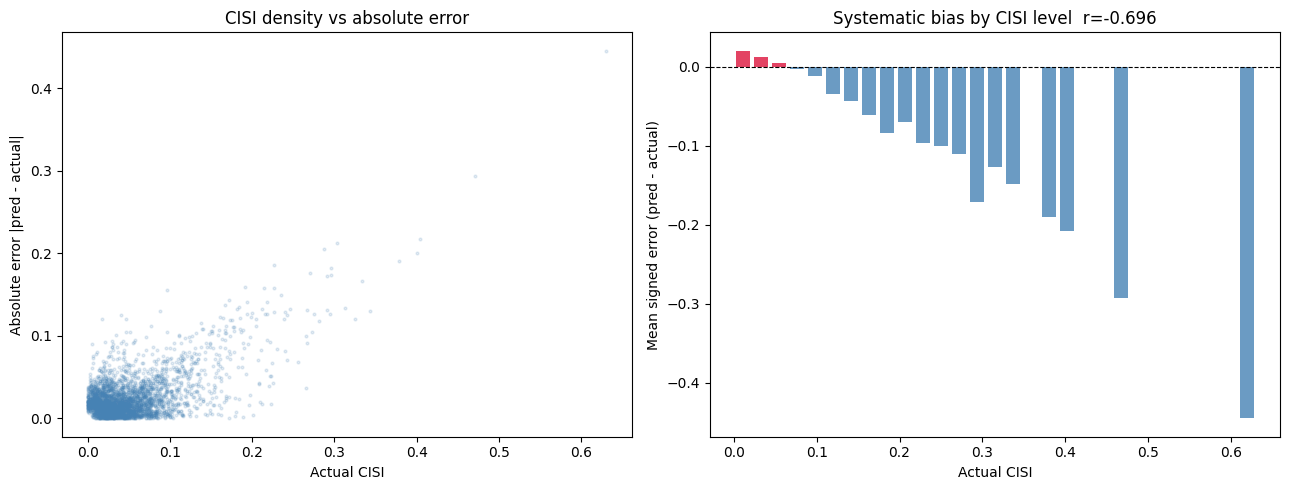

In [26]:
from scipy.stats import pearsonr, binned_statistic

abs_error    = np.abs(preds - targets)
signed_error = preds - targets

bins        = np.linspace(0, targets.max(), 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

mean_abs_err,    _, _ = binned_statistic(targets, abs_error,    statistic='mean', bins=bins)
mean_signed_err, _, _ = binned_statistic(targets, signed_error, statistic='mean', bins=bins)

r, p = pearsonr(targets, signed_error)
print(f'Pearson r (CISI vs signed error): {r:.4f}  p={p:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(targets, abs_error, alpha=0.15, s=4, color='steelblue')
axes[0].set_xlabel('Actual CISI')
axes[0].set_ylabel('Absolute error |pred - actual|')
axes[0].set_title('CISI density vs absolute error')

bar_colors = ['crimson' if v > 0 else 'steelblue' for v in mean_signed_err]
axes[1].bar(bin_centers, mean_signed_err, width=(bins[1]-bins[0])*0.8, color=bar_colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Actual CISI')
axes[1].set_ylabel('Mean signed error (pred - actual)')
axes[1].set_title(f'Systematic bias by CISI level  r={r:.3f}')

plt.tight_layout()
plt.savefig('figures/italy_error_vs_cisi_11_5_2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Pixel distribution — actual vs predicted CISI (Italy)

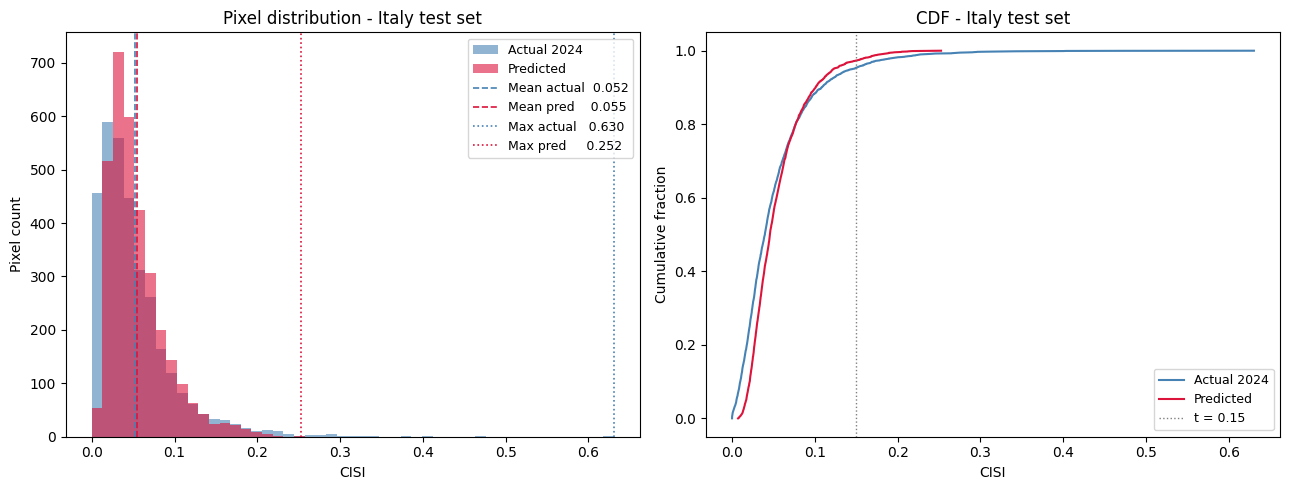

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins = np.linspace(0, max(targets.max(), preds.max()), 50)

axes[0].hist(targets, bins=bins, alpha=0.6, color='steelblue', label='Actual 2024')
axes[0].hist(preds,   bins=bins, alpha=0.6, color='crimson',   label='Predicted')
axes[0].axvline(targets.mean(), color='steelblue', linestyle='--', linewidth=1.2, label=f'Mean actual  {targets.mean():.3f}')
axes[0].axvline(preds.mean(),   color='crimson',   linestyle='--', linewidth=1.2, label=f'Mean pred    {preds.mean():.3f}')
axes[0].axvline(targets.max(),  color='steelblue', linestyle=':',  linewidth=1.2, label=f'Max actual   {targets.max():.3f}')
axes[0].axvline(preds.max(),    color='crimson',   linestyle=':',  linewidth=1.2, label=f'Max pred     {preds.max():.3f}')
axes[0].set_xlabel('CISI')
axes[0].set_ylabel('Pixel count')
axes[0].set_title('Pixel distribution - Italy test set')
axes[0].legend(fontsize=9)

axes[1].plot(np.sort(targets), np.linspace(0, 1, len(targets)), color='steelblue', label='Actual 2024')
axes[1].plot(np.sort(preds),   np.linspace(0, 1, len(preds)),   color='crimson',   label='Predicted')
axes[1].axvline(0.15, color='grey', linestyle=':', linewidth=1, label='t = 0.15')
axes[1].set_xlabel('CISI')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('CDF - Italy test set')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/cisi_distribution_11_5_2026.png', dpi=150, bbox_inches='tight')
plt.show()